# 06 · Conclusiones e Interpretación de Resultados
---


In [1]:
import sys, os
sys.path.append("..")
os.makedirs("../reports", exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110})
COLORS = ["#4C9BE8", "#F0A500", "#E05A5A"]

df_m = pd.read_csv("../reports/tables/metricas_finales.csv")
df_m


,Modelo,Accuracy,F1 ponderado,Recall ponderado,Precision ponderada
0,Arbol de Decision,0.6508,0.6181,0.6508,0.6095
1,Random Forest,0.6480,0.6126,0.6480,0.6032
2,Gradient Boosting,0.6268,0.6121,0.6268,0.6040


In [2]:
display(df_m.style.set_caption('Resumen final — Métricas de evaluación').highlight_max(axis=0,color="#30680c",subset=['Accuracy','F1 ponderado','Recall ponderado','Precision ponderada']).hide(axis='index'))


Modelo,Accuracy,F1 ponderado,Recall ponderado,Precision ponderada
Arbol de Decision,0.650800,0.618100,0.650800,0.609500
Random Forest,0.648000,0.612600,0.648000,0.603200
Gradient Boosting,0.626800,0.612100,0.626800,0.604000


En resumen, todos los modelos tienen un rendimiento bastante parecido, lo que indica que ninguno está dominando claramente el problema, sino que todos están aprendiendo de forma similar a partir de los datos. Aun así, se pueden notar pequeñas diferencias, hay un modelo que logra un mejor equilibrio general entre las métricas, mientras que otros pueden destacar ligeramente en aspectos específicos.

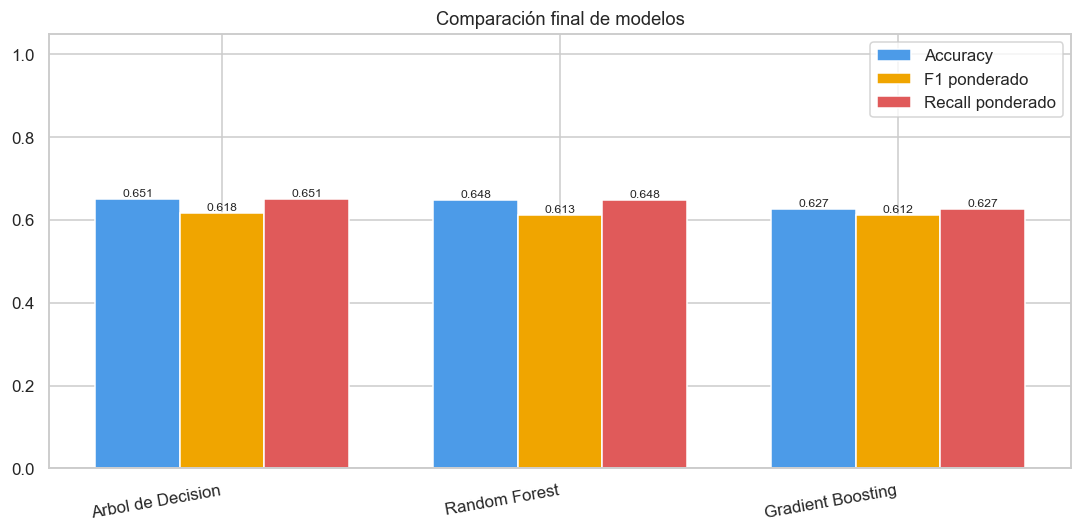

In [3]:
metricas_cols = ["Accuracy", "F1 ponderado", "Recall ponderado"]
x = np.arange(len(df_m))
w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))

for j, (met, col) in enumerate(zip(metricas_cols, COLORS)):
    bars = ax.bar(x + (j-1)*w, df_m[met], w, label=met, color=col, edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f"{h:.3f}", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(df_m["Modelo"], rotation=10, ha="right")
ax.set_ylim(0, 1.05)
ax.set_title("Comparación final de modelos")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/conclusiones_comparacion.png", dpi=110, bbox_inches="tight")
plt.show()


La gráfica confirma de forma visual lo que ya se observa en la tabla, los modelos tienen un comportamiento muy similar y no hay uno que sobresalga de manera contundente.

## Conclusiones 
### 1. Comprensión del problema y análisis exploratorio
El análisis exploratorio permitió comprender que la severidad de los accidentes de tránsito no está determinada por una única variable, sino por la interacción de múltiples factores. Sin embargo, no se identificaron patrones claros ni relaciones fuertes entre las variables y las clases de severidad, ya que las distribuciones se mostraron similares entre categorías. Esto demuestra que el problema de clasificación de variables es complejo y no son facil de identificar a simple vista.
### 2. Preparación y calidad de los datos
Durante la preparación de los datos se realizaron procesos de limpieza, imputación y transformación que permitieron estructurar el dataset de forma adecuada para los modelos. A pesar de esto, la calidad de la información disponible y la ausencia de variables más descriptivas limitan la capacidad de los modelos para diferenciar con claridad los niveles de severidad.
### 3. Feature engineering y construcción de variables
Se implementaron variables derivadas basadas en conocimiento del dominio como: conducción nocturna, condiciones climáticas adversas y combinaciones de factores de riesgo. Sin embargo, el análisis estadístico mostró que estas variables no presentan una relación significativa de forma individual con la severidad del accidente, lo que demuestra que su aporte se da principalmente en interacción con otras variables dentro de los modelos.

### 4. Modelado y comparación de modelos
En la etapa de modelado se entrenaron y compararon diferentes modelos, donde se identifico que el Árbol de Decisión presenta el mejor desempeño global en términos de accuracy y F1 ponderado, aunque con diferencias mínimas frente a Random Forest y Gradient Boosting. Esto indica que ningún modelo logra capturar completamente la complejidad del problema, pero sí permiten identificar tendencias generales en los datos.

### 5. Evaluación del desempeño y comunicación de resultados
La evaluación de los modelos evidenció que el desempeño varía significativamente entre clases. Todos los modelos presentan resultados casi perfectos en la clase fatal, un buen desempeño en la clase minor, pero dificultades importantes en la clase major, reflejadas en un bajo recall. Esto indica que el modelo no falla en la identificación de los casos extremos, sino en la clasificación de situaciones intermedias, donde existe mayor ambigüedad en los datos.

De esta forma, los resultados fueron mostrados mediante gráficas, tablas y una aplicación en Streamlit, facilitando su interpretación. Sin embargo, el modelo debe entenderse como una herramienta de apoyo analítico y no como un sistema de predicción confiable, debido a las limitaciones del dataset.

En conclusión, el proyecto demuestra que la predicción de la severidad de accidentes de tránsito es un problema complejo, donde los modelos logran identificar correctamente los casos más evidentes, pero presentan dificultades en escenarios intermedios. Esto resalta la importancia de contar con datos más precisos y variables más representativas para mejorar la capacidad predictiva y la utilidad práctica de los modelos desarrollados.

